# 🌊 Large Geospatial Open Ocean Datasets

**Instructor:** Dr. Laique Djeutchouang  

### A Practical Guide for Marine & Climate Scientists

---

This notebook provides a workshop-ready overview of **five major open-access geospatial ocean datasets**:

| # | Dataset | Variable | Provider |
|---|---------|----------|----------|
| 1 | **SOCAT** | Surface Ocean CO₂ (fCO₂) | ICOS / GEOMAR |
| 2 | **GlobColour** | Ocean Colour / Chlorophyll-a | Copernicus Marine (CMEMS) |
| 3 | **ERA5** | Atmospheric Reanalysis | ECMWF / Copernicus CDS |
| 4 | **NOAA OISST** | Sea Surface Temperature | NOAA NCEI |
| 5 | **UK Met Office EN4** | Sub-surface Salinity & Temperature | Met Office Hadley Centre |

Each section covers: **what the dataset is**, **its key variables and specifications**, **the dataset URL**, and **how to download it programmatically in Python**.

---

## 🔧 Environment Setup

Run this cell once to install all libraries needed across all five datasets.

In [1]:
# Install all required packages
# Run once per environment

import subprocess, sys

packages = [
    "cdsapi",          # ERA5 / Copernicus CDS API
    "copernicusmarine",# GlobColour / CMEMS API
    "xarray",          # NetCDF / multidimensional data
    "netCDF4",         # NetCDF backend
    "pandas",          # Tabular data (SOCAT TSV)
    "numpy",
    "matplotlib",
    "cartopy",         # Map projections
    "requests",        # HTTP downloads (SOCAT, EN4, OISST)
    "tqdm",
    'h5py',# Progress bars
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ All packages installed successfully.")


✅ All packages installed successfully.


---

# 1. SOCAT — Surface Ocean CO₂ Atlas

## 📖 Description

**SOCAT** (Surface Ocean CO₂ Atlas) is the world's largest community-curated synthesis of quality-controlled surface ocean CO₂ fugacity (fCO₂) observations. It is produced by an international consortium of more than 100 marine carbon scientists and is a core product of the **Global Ocean Observing System (GOOS)**.

The latest release, **SOCATv2025**, contains over **41.4 million observations** collected from 1957 to 2023 across global oceans and coastal seas. Measurements are gathered from ships, moorings, drifters, sailing yachts, and autonomous platforms (e.g., saildrones). Each data point has an estimated accuracy of **< ±5 µatm** for the main synthesis products.

SOCAT is released annually and underpins the **Global Carbon Budget** (published every year by the Global Carbon Project), helping quantify how much CO₂ the ocean absorbs from the atmosphere. It contributes directly to **UN SDG 13 (Climate Action)** and **SDG 14 (Life Below Water)**.

### 📦 Data Products

| Product | Description | Resolution |
|---------|-------------|------------|
| **Synthesis files** | Full individual cruise/mooring/drifter datasets (TSV format) | Point observations |
| **Gridded product (global)** | Monthly mean fCO₂ on a 1° × 1° grid | 1° × 1°, monthly |
| **Gridded product (coastal)** | Monthly mean fCO₂ for coastal seas | 0.25° × 0.25°, monthly |

### 🔑 Key Variables
- `fCO2rec` — Recommended fCO₂ value (µatm)
- `SST` — Sea surface temperature (°C)
- `sal` — Salinity (PSU)
- `WOCE_CO2_water` — Quality flag (2 = good, 3 = questionable, 4 = bad)
- `year`, `mon`, `day`, `hh`, `mm`, `ss` — Timestamp
- `longitude`, `latitude` — Position

### 🌐 Dataset URL
> **Main portal:** https://socat.info  
> **Direct data download:** https://socat.info/index.php/data-access/  
> **NCEI archive (v2025):** https://www.ncei.noaa.gov/data/oceans/ncei/ocads/metadata/0304549.html  
> **License:** Creative Commons Attribution 4.0 (CC-BY 4.0)

---

## ⬇️ Download SOCAT Data

In [2]:
# ─────────────────────────────────────────────────────────────────
# SOCAT — Download the gridded product (NetCDF)
# The gridded dataset is ideal for map-based analyses and
# comparisons with other gridded products (SST, winds, etc.)
# ─────────────────────────────────────────────────────────────────

import requests
from tqdm import tqdm
import os

# ── Option A: Download the gridded NetCDF product (1°×1° global) ──
# This URL points to the SOCATv2024 global gridded NetCDF.
# Check https://socat.info/index.php/data-access/ for the latest version URL.

SOCAT_GRIDDED_URL = (
    "https://socat.info/socat_files/v2024/SOCATv2024_tracks_gridded_monthly.nc.zip"
)
SOCAT_GRIDDED_FILE = "SOCATv2024_gridded_monthly.nc.zip"

def download_file(url, filename, chunk_size=1024*1024):
    """Stream-download a file with a progress bar."""
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    total = int(response.headers.get("content-length", 0))
    with open(filename, "wb") as f, tqdm(
        desc=filename, total=total, unit="B",
        unit_scale=True, unit_divisor=1024
    ) as bar:
        for chunk in response.iter_content(chunk_size=chunk_size):
            f.write(chunk)
            bar.update(len(chunk))
    print(f"✅ Downloaded: {filename}")

# Download gridded product
if not os.path.exists(SOCAT_GRIDDED_FILE):
    download_file(SOCAT_GRIDDED_URL, SOCAT_GRIDDED_FILE)
else:
    print(f"📂 File already exists: {SOCAT_GRIDDED_FILE}")


📂 File already exists: SOCATv2024_gridded_monthly.nc.zip


In [3]:
# ── Option B: Download the full synthesis TSV file ──
# Contains all individual observations (large: ~500 MB compressed).
# Each row is one fCO2 measurement with metadata.

SOCAT_SYNTHESIS_URL = "https://socat.info/socat_files/v2024/SOCATv2024.tsv.zip"
SOCAT_SYNTHESIS_FILE = "SOCATv2024.tsv.zip"

# Uncomment to download (large file ~500 MB compressed):
# download_file(SOCAT_SYNTHESIS_URL, SOCAT_SYNTHESIS_FILE)


In [4]:
# ── Quick look at the gridded NetCDF ──
import zipfile
import xarray as xr

# Unzip if needed
nc_file = SOCAT_GRIDDED_FILE.replace(".zip", "")
if not os.path.exists(nc_file):
    with zipfile.ZipFile(SOCAT_GRIDDED_FILE, "r") as z:
        z.extractall(".")
        nc_file = [f for f in z.namelist() if f.endswith(".nc")][0]
    print(f"📦 Extracted: {nc_file}")

# Open and inspect
ds = xr.open_dataset(nc_file)
print(ds)


📦 Extracted: SOCATv2024_tracks_gridded_monthly.nc
<xarray.Dataset> Size: 5GB
Dimensions:                (tmnth: 648, bnds: 2, ylat: 180, xlon: 360)
Coordinates:
  * xlon                   (xlon) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * ylat                   (ylat) float64 1kB -89.5 -88.5 -87.5 ... 88.5 89.5
  * tmnth                  (tmnth) datetime64[ns] 5kB 1970-01-16T12:00:00 ......
Dimensions without coordinates: bnds
Data variables: (12/25)
    tmnth_bnds             (tmnth, bnds) datetime64[ns] 10kB ...
    count_ncruise          (tmnth, ylat, xlon) float64 336MB ...
    fco2_count_nobs        (tmnth, ylat, xlon) float64 336MB ...
    fco2_ave_weighted      (tmnth, ylat, xlon) float32 168MB ...
    fco2_ave_unwtd         (tmnth, ylat, xlon) float32 168MB ...
    fco2_min_unwtd         (tmnth, ylat, xlon) float32 168MB ...
    ...                     ...
    salinity_min_unwtd     (tmnth, ylat, xlon) float32 168MB ...
    salinity_max_unwtd     (tmnth, ylat, xlon) float32 1

/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/C

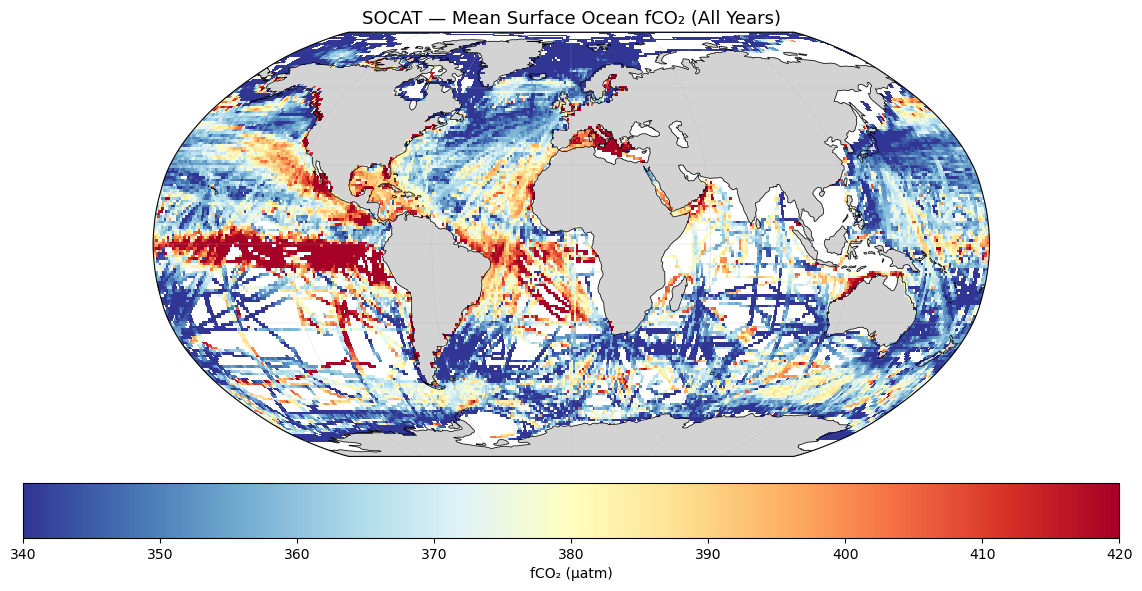

In [5]:
# ── Quick map: mean fCO2 over the record ──
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# The main fCO2 variable in the gridded product is 'fco2_ave_unwtd'
fco2_mean = ds["fco2_ave_unwtd"].mean(dim="tmnth", skipna=True)

fig, ax = plt.subplots(
    figsize=(14, 6),
    subplot_kw={"projection": ccrs.Robinson()}
)
ax.add_feature(cfeature.LAND, color="lightgray")
ax.coastlines(linewidth=0.5)
ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)

p = ax.pcolormesh(
    ds.xlon, ds.ylat, fco2_mean,
    transform=ccrs.PlateCarree(),
    cmap="RdYlBu_r", vmin=340, vmax=420
)
fig.colorbar(p, ax=ax, orientation="horizontal",
             label="fCO₂ (µatm)", pad=0.05, shrink=0.8)
ax.set_title("SOCAT — Mean Surface Ocean fCO₂ (All Years)", fontsize=13)
fig.tight_layout()
#plt.show()


---

# 2. GlobColour — Global Ocean Colour

## 📖 Description

**GlobColour** is the Copernicus Marine Service's (CMEMS) global ocean-colour bio-geo-chemical (BGC) dataset, produced by **ACRI-ST** using the Copernicus-GlobColour processor. It merges data from multiple satellite sensors — including **SeaWiFS, MODIS, MERIS, VIIRS, and OLCI (Sentinel-3A/B)** — into a single, harmonised, gap-reduced product.

The multi-year record runs **from 1997 to present**, making it one of the longest satellite ocean colour time series available. It is delivered at two spatial resolutions: **4 km** (multi-sensor) and **300 m** (OLCI-only). Products are available as Level-3 (daily composites with some cloud gaps) and Level-4 (monthly, gap-filled by interpolation).

GlobColour is widely used for monitoring phytoplankton dynamics, marine primary production, ocean turbidity, and the response of marine ecosystems to climate variability.

### 📦 Key Variables

| Variable | Description |
|----------|-------------|
| `CHL` | Chlorophyll-a concentration (mg m⁻³) |
| `SPM` | Suspended Particulate Matter (g m⁻³) |
| `ZSD` | Secchi Transparency Depth (m) |
| `KD490` | Diffuse Attenuation Coefficient at 490 nm (m⁻¹) |
| `BBP` | Particulate Backscattering coefficient (m⁻¹) |
| `CDM` | Coloured Dissolved & Detrital Matter absorption |
| `RRS` | Remote Sensing Reflectance at multiple bands |
| `PFT` | Phytoplankton Functional Types |

### 🌐 Dataset URLs
> **CMEMS Product page (L3 daily, multi-year):**  
> https://data.marine.copernicus.eu/product/OCEANCOLOUR_GLO_BGC_L3_MY_009_103  
> **CMEMS Product page (L4 monthly, multi-year):**  
> https://data.marine.copernicus.eu/product/OCEANCOLOUR_GLO_BGC_L4_MY_009_104  
> **License:** Copernicus Marine Service SLA (free, registration required)

> **🔑 Requires:** Free registration at https://marine.copernicus.eu/

---

## ⬇️ Download GlobColour Data

In [6]:
# ─────────────────────────────────────────────────────────────────
# GlobColour — Download via the Copernicus Marine Toolbox (copernicusmarine)
# Register for free at: https://marine.copernicus.eu/
# ─────────────────────────────────────────────────────────────────

import copernicusmarine

# ── Step 1: Login (one-time; credentials are saved locally) ──
copernicusmarine.login()  # Uncomment and run once interactively

# ── Step 2: Subset and download Chlorophyll-a (L4 monthly, global) ──
# Dataset ID for the L4 monthly multi-year product
DATASET_ID = "cmems_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M"

copernicusmarine.subset(
    dataset_id = DATASET_ID,
    variables  = ["CHL"],              # Chlorophyll-a
    start_datetime = "2020-01-01T00:00:00",
    end_datetime   = "2020-12-31T23:59:59",
    minimum_longitude = -80,
    maximum_longitude =  20,
    minimum_latitude  = -60,
    maximum_latitude  =  30,
    output_filename   = "globcolour_CHL_2020.nc",
    output_directory  = "./data/",
)

print("✅ GlobColour CHL downloaded to ./data/globcolour_CHL_2020.nc")


INFO - 2026-03-18T17:53:56Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  dbarreto


Copernicus Marine password:

  ········


File /Users/dlizarbe/.copernicusmarine/.copernicusmarine-credentials already exists, overwrite it ? [y/N]:

  y


INFO - 2026-03-18T17:55:20Z - Credentials file stored in /Users/dlizarbe/.copernicusmarine/.copernicusmarine-credentials.
INFO - 2026-03-18T17:55:25Z - Selected dataset version: "202411"
INFO - 2026-03-18T17:55:25Z - Selected dataset part: "default"
WARNING - 2026-03-18T17:55:25Z - You are using the dataset cmems_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M, version '202411', part 'default'. This exact version and part of the dataset will be retired on the 2026-03-31T13:00:00.000Z. For more information you can check: https://marine.copernicus.eu/user-corner/product-roadmap/transition-information


  0%|          | 0/163 [00:00<?, ?it/s]

✅ GlobColour CHL downloaded to ./data/globcolour_CHL_2020.nc


In [7]:
# ── Alternative: lazy-load via OPeNDAP (no local copy needed) ──
# This is memory-efficient for large spatial/temporal subsets.

import xarray as xr

ds_chl = copernicusmarine.open_dataset(
    dataset_id = DATASET_ID,
    variables  = ["CHL"],
    start_datetime = "2020-06-01T00:00:00",
    end_datetime   = "2020-06-30T23:59:59",
    minimum_longitude = -80,
    maximum_longitude =  20,
    minimum_latitude  = -60,
    maximum_latitude  =  30,
)
print(ds_chl)


INFO - 2026-03-18T17:56:25Z - Selected dataset version: "202411"
INFO - 2026-03-18T17:56:25Z - Selected dataset part: "default"
WARNING - 2026-03-18T17:56:25Z - You are using the dataset cmems_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M, version '202411', part 'default'. This exact version and part of the dataset will be retired on the 2026-03-31T13:00:00.000Z. For more information you can check: https://marine.copernicus.eu/user-corner/product-roadmap/transition-information


<xarray.Dataset> Size: 21MB
Dimensions:    (time: 1, latitude: 2160, longitude: 2400)
Coordinates:
  * latitude   (latitude) float32 9kB -59.98 -59.94 -59.9 ... 29.9 29.94 29.98
  * longitude  (longitude) float32 10kB -79.98 -79.94 -79.9 ... 19.9 19.94 19.98
  * time       (time) datetime64[ns] 8B 2020-06-01
Data variables:
    CHL        (time, latitude, longitude) float32 21MB ...
Attributes: (12/92)
    Conventions:                     CF-1.8, ACDD-1.3
    DPM_reference:                   GC-UD-ACRI-PUG
    IODD_reference:                  GC-UD-ACRI-PUG
    acknowledgement:                 The Licensees will ensure that original ...
    citation:                        The Licensees will ensure that original ...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L4_MY_009_104
    ...                              ...
    time_coverage_resolution:        P30D
    time_coverage_start:             2024-08-31T19:56:18Z
    title:                           cmems_obs-oc_glo_bgc-plan

/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/C

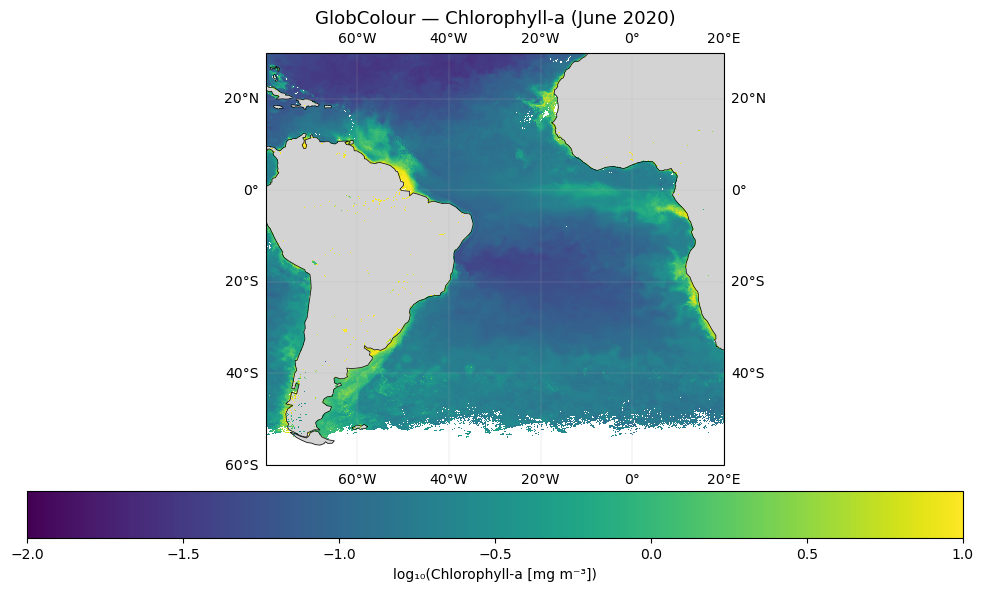

In [8]:
# ── Quick plot: Chlorophyll-a June 2020 ──
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

chl = ds_chl["CHL"].isel(time=0)

fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
ax.add_feature(cfeature.LAND, color="lightgray")
ax.coastlines(linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

p = ax.pcolormesh(
    chl.longitude, chl.latitude, np.log10(chl),
    transform=ccrs.PlateCarree(), cmap="viridis", vmin=-2, vmax=1
)
cbar = plt.colorbar(p, ax=ax, orientation="horizontal",
                    label="log₁₀(Chlorophyll-a [mg m⁻³])",
                    pad=0.05, shrink=0.8)
ax.set_title("GlobColour — Chlorophyll-a (June 2020)", fontsize=13)
fig.tight_layout()
#plt.show()


---

# 3. ERA5 — ECMWF Reanalysis v5

## 📖 Description

**ERA5** is the fifth-generation global atmospheric reanalysis produced by the **European Centre for Medium-Range Weather Forecasts (ECMWF)** and made freely available through the **Copernicus Climate Change Service (C3S)**. It is widely considered the gold standard for atmospheric forcing fields in ocean modelling and air-sea flux studies.

ERA5 combines observations from thousands of data sources (radiosondes, satellites, aircraft, buoys, ships) with a state-of-the-art numerical weather prediction model via **4D-Var data assimilation** to produce a spatially and temporally complete global dataset. The archive runs **from 1940 to 2–5 days behind real time**, with hourly output at **~31 km (0.25°) horizontal resolution** and 137 model levels in the vertical.

For oceanographic applications, the most commonly used ERA5 variables include surface winds, heat fluxes, precipitation, and sea-level pressure — all essential for computing air-sea exchanges.

### 📦 Key Products

| Product | Description |
|---------|-------------|
| **Single levels (hourly)** | Near-surface atmospheric fields (10m winds, 2m T, precip, fluxes) |
| **Single levels (monthly means)** | Monthly averages of the above |
| **Pressure levels (hourly)** | 3D atmospheric fields at 37 pressure levels |
| **ERA5-Land** | Higher resolution (0.1°) land surface variables |

### 🔑 Key Variables (for ocean science)
- `u10`, `v10` — 10-m wind components (m s⁻¹)
- `sst` — Sea surface temperature (K)
- `msl` — Mean sea-level pressure (Pa)
- `tp` — Total precipitation (m)
- `slhf`, `sshf` — Latent and sensible heat fluxes (J m⁻²)
- `t2m` — 2-metre air temperature (K)
- `d2m` — 2-metre dewpoint (K)

### 🌐 Dataset URLs
> **CDS Portal (hourly, single levels):**  
> https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels  
> **CDS API setup guide:**  
> https://cds.climate.copernicus.eu/how-to-api  
> **License:** Copernicus License (free with registration)

> **🔑 Requires:** Free account at https://cds.climate.copernicus.eu/

---

## ⚙️ ERA5 — One-time API Key Setup

After creating a free CDS account, copy your **Personal Access Token** and save it to `~/.cdsapirc`:

```
url: https://cds.climate.copernicus.eu/api
key: YOUR_PERSONAL_ACCESS_TOKEN
```

You can also do this programmatically:

In [1]:
# ─────────────────────────────────────────────────────────────────
# ERA5 — Write CDS API credentials (run once)
# Replace YOUR_TOKEN with your actual token from:
# https://cds.climate.copernicus.eu/profile
# ─────────────────────────────────────────────────────────────────

import os

CDS_URL   = "https://cds.climate.copernicus.eu/api"
CDS_TOKEN = "a69bffd5-d927-4e70-822e-5c7d6134cf41"  # ← Replace this

cdsapirc_path = os.path.expanduser("~/.cdsapirc")
# with open(cdsapirc_path, "w") as f:
#     f.write(f"url: {CDS_URL}\nkey: {CDS_TOKEN}\n")
# print(f"✅ Created ~/.cdsapirc")

if not os.path.exists(cdsapirc_path):
    with open(cdsapirc_path, "w") as f:
        f.write(f"url: {CDS_URL}\nkey: {CDS_TOKEN}\n")
    print(f"✅ Created ~/.cdsapirc")
else:
    print("📂 ~/.cdsapirc already exists — no changes made.")


📂 ~/.cdsapirc already exists — no changes made.


In [2]:
# ─────────────────────────────────────────────────────────────────
# ERA5 — Download monthly-mean 10m winds & SST (NetCDF)
# ─────────────────────────────────────────────────────────────────

import cdsapi

client = cdsapi.Client()

client.retrieve(
    "reanalysis-era5-single-levels-monthly-means",
    {
        "product_type": "monthly_averaged_reanalysis",
        "variable": [
            "10m_u_component_of_wind",
            "10m_v_component_of_wind",
            "sea_surface_temperature",
            "mean_sea_level_pressure",
        ],
        "year":  [str(y) for y in range(2015, 2021)],
        "month": [f"{m:02d}" for m in range(1, 13)],
        "time":  "00:00",
        "area":  [30, -80, -60, 20],  # [North, West, South, East]
        "data_format": "netcdf",
    },
    "era5_monthly_winds_sst_2015_2020.nc",
)

print("✅ ERA5 monthly data downloaded.")

# url: https://cds.climate.copernicus.eu/api
# key: a69bffd5-d927-4e70-822e-5c7d6134cf41

HTTPError: 403 Client Error: Forbidden for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/reanalysis-era5-single-levels-monthly-means/execution
required licences not accepted
Not all the required licences have been accepted; please visit https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=download#manage-licences to accept the required licence(s).

In [15]:
# ── Open and inspect the ERA5 file ──
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

ds_era5 = xr.open_dataset("era5_monthly_winds_sst_2015_2020.nc")
print(ds_era5)

# ── Plot: mean 10m wind speed ──
u10 = ds_era5["u10"].mean(dim="valid_time")
v10 = ds_era5["v10"].mean(dim="valid_time")
wspd = np.sqrt(u10**2 + v10**2)

fig, ax = plt.subplots(
    figsize=(12, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
ax.add_feature(cfeature.LAND, color="lightgray")
ax.coastlines(linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

p = ax.pcolormesh(
    wspd.longitude, wspd.latitude, wspd,
    transform=ccrs.PlateCarree(), cmap="YlOrRd", vmin=0, vmax=12
)
# Overlay wind vectors (thinned for clarity)
skip = 5
ax.quiver(
    u10.longitude.values[::skip], u10.latitude.values[::skip],
    u10.values[::skip, ::skip],   v10.values[::skip, ::skip],
    transform=ccrs.PlateCarree(), scale=200, width=0.003, alpha=0.6
)
plt.colorbar(p, ax=ax, label="Wind Speed (m s⁻¹)", shrink=0.8)
ax.set_title("ERA5 — Mean 10 m Wind Speed + Direction (2015–2020)", fontsize=13)
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/dlizarbe/Documents/SOLAS_summerschool/Laique_class/era5_monthly_winds_sst_2015_2020.nc'

---

# 4. NOAA OISST — Optimum Interpolation Sea Surface Temperature

## 📖 Description

**NOAA OISST v2.1** (also known as *Reynolds SST*) is a long-term **Climate Data Record** of daily, globally gridded sea surface temperature at **0.25° × 0.25° horizontal resolution**, produced by the **NOAA National Centers for Environmental Information (NCEI)**.

The product blends observations from multiple platforms — primarily **AVHRR infrared satellite** retrievals, supplemented by ships, buoys, and Argo floats — using **Optimum Interpolation (OI)** to fill spatial gaps and produce a complete, gap-free daily field. Bias correction is applied to satellite data using in situ buoy observations. The archive extends from **1 September 1981 to near-real time** (1-day latency for the preliminary version; 2-week latency for the final version).

OISST is extensively used for detecting **marine heatwaves**, characterising **ENSO events**, providing forcing for ocean and biogeochemical models, and for fisheries ecology studies.

### 📦 Key Variables

| Variable | Description |
|----------|-------------|
| `sst` | Sea surface temperature (°C) |
| `anom` | SST anomaly relative to the 1971–2000 climatology (°C) |
| `err` | Estimated SST error standard deviation (°C) |
| `ice` | Sea ice concentration (0–1) |

### 🌐 Dataset URLs
> **NCEI Product page:**  
> https://www.ncei.noaa.gov/products/optimum-interpolation-sst  
> **Direct FTP/HTTPS file access:**  
> https://www.ncei.noaa.gov/data/sea-surface-temperature-optimum-interpolation/v2.1/access/avhrr/  
> **ERDDAP (OPeNDAP, subset downloads):**  
> https://coastwatch.pfeg.noaa.gov/erddap/griddap/ncdcOisst21Agg_LonPM180.html  
> **License:** Public Domain (U.S. Government work)

---

## ⬇️ Download NOAA OISST Data

In [16]:
# ─────────────────────────────────────────────────────────────────
# NOAA OISST — Method 1: Direct HTTPS download of daily NetCDF files
# Files are named: oisst-avhrr-v02r01.YYYYMMDD.nc
# ─────────────────────────────────────────────────────────────────

import requests, os
from tqdm import tqdm

OISST_BASE = (
    "https://www.ncei.noaa.gov/data/"
    "sea-surface-temperature-optimum-interpolation/"
    "v2.1/access/avhrr/"
)

def oisst_url(year, month, day):
    """Construct the URL for a single daily OISST file."""
    return (
        f"{OISST_BASE}{year}{month:02d}/"
        f"oisst-avhrr-v02r01.{year}{month:02d}{day:02d}.nc"
    )

def download_oisst_day(year, month, day, out_dir="./data/oisst"):
    os.makedirs(out_dir, exist_ok=True)
    url = oisst_url(year, month, day)
    fname = os.path.join(out_dir, os.path.basename(url))
    if os.path.exists(fname):
        print(f"📂 Already exists: {fname}")
        return fname
    r = requests.get(url, stream=True, timeout=60)
    r.raise_for_status()
    with open(fname, "wb") as f:
        for chunk in r.iter_content(1024 * 512):
            f.write(chunk)
    print(f"✅ Downloaded: {fname}")
    return fname

# Example: download one week of SST in January 2022
files = []
for day in range(1, 8):
    files.append(download_oisst_day(2022, 1, day))


✅ Downloaded: ./data/oisst/oisst-avhrr-v02r01.20220101.nc
✅ Downloaded: ./data/oisst/oisst-avhrr-v02r01.20220102.nc
✅ Downloaded: ./data/oisst/oisst-avhrr-v02r01.20220103.nc
✅ Downloaded: ./data/oisst/oisst-avhrr-v02r01.20220104.nc
✅ Downloaded: ./data/oisst/oisst-avhrr-v02r01.20220105.nc
✅ Downloaded: ./data/oisst/oisst-avhrr-v02r01.20220106.nc
✅ Downloaded: ./data/oisst/oisst-avhrr-v02r01.20220107.nc


In [20]:
# ── Method 2: OPeNDAP via ERDDAP — no local download needed ──
# Uses xarray to stream a spatial/temporal subset directly into memory.

da = xr.open_mfdataset('./data/oisst/oisst-avhrr-v02r01.202201*.nc')
da

<xarray.Dataset> Size: 116MB
Dimensions:  (time: 7, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 56B 2022-01-01T12:00:00 ... 2022-01-07T12:...
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, zlev, lat, lon) float32 29MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    anom     (time, zlev, lat, lon) float32 29MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    err      (time, zlev, lat, lon) float32 29MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float32 29MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    Conventions:                CF-1.6, ACDD-1.3
    title:                      NOAA/NCEI 1/4 Degree Daily Optimum Interpolat...
    references:                 Reynolds, et al.(2007) Daily High-Resolution-...
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    id:                         oisst-avhrr-v02r01.20220101.nc
    naming_authority:           gov.noaa.ncei
    ...                         ...
    time_coverage_start:        2022-01-01T00:00:00Z
    time_coverage_end:          2022-01-01T23:59:59Z
    metadata_link:              https://doi.org/10.25921/RE9P-PT57
    ncei_template_version:      NCEI_NetCDF_Grid_Template_v2.0
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    sensor:                     Thermometer, AVHRR

In [21]:
# If using files downloaded in Method 1:
ds_sst = xr.open_mfdataset("./data/oisst/*.nc", combine="by_coords")
ds_sst


<xarray.Dataset> Size: 116MB
Dimensions:  (time: 7, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 56B 2022-01-01T12:00:00 ... 2022-01-07T12:...
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, zlev, lat, lon) float32 29MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    anom     (time, zlev, lat, lon) float32 29MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    err      (time, zlev, lat, lon) float32 29MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float32 29MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    Conventions:                CF-1.6, ACDD-1.3
    title:                      NOAA/NCEI 1/4 Degree Daily Optimum Interpolat...
    references:                 Reynolds, et al.(2007) Daily High-Resolution-...
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    id:                         oisst-avhrr-v02r01.20220101.nc
    naming_authority:           gov.noaa.ncei
    ...                         ...
    time_coverage_start:        2022-01-01T00:00:00Z
    time_coverage_end:          2022-01-01T23:59:59Z
    metadata_link:              https://doi.org/10.25921/RE9P-PT57
    ncei_template_version:      NCEI_NetCDF_Grid_Template_v2.0
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    sensor:                     Thermometer, AVHRR

/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/C

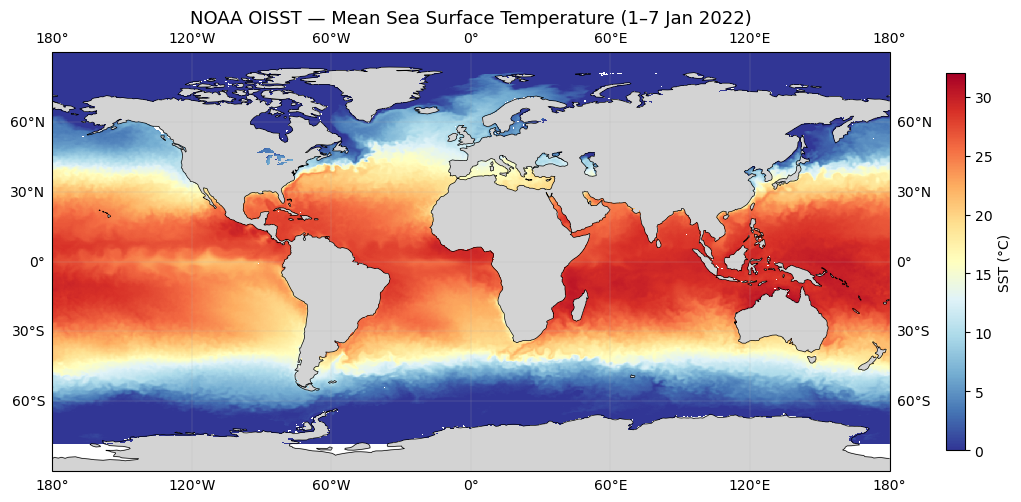

In [22]:
# ── Plot: mean SST first week of January 2022 ──
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sst_mean = ds_sst["sst"].isel(zlev=0).mean(dim="time")

fig, ax = plt.subplots(
    figsize=(12, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
ax.add_feature(cfeature.LAND, color="lightgray")
ax.coastlines(linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

p = ax.pcolormesh(
    sst_mean.lon, sst_mean.lat, sst_mean,
    transform=ccrs.PlateCarree(), cmap="RdYlBu_r", vmin=0, vmax=32
)
fig.colorbar(p, ax=ax, label="SST (°C)", shrink=0.9)
ax.set_title("NOAA OISST — Mean Sea Surface Temperature (1–7 Jan 2022)", fontsize=13)
fig.tight_layout()
#plt.show()


/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/C

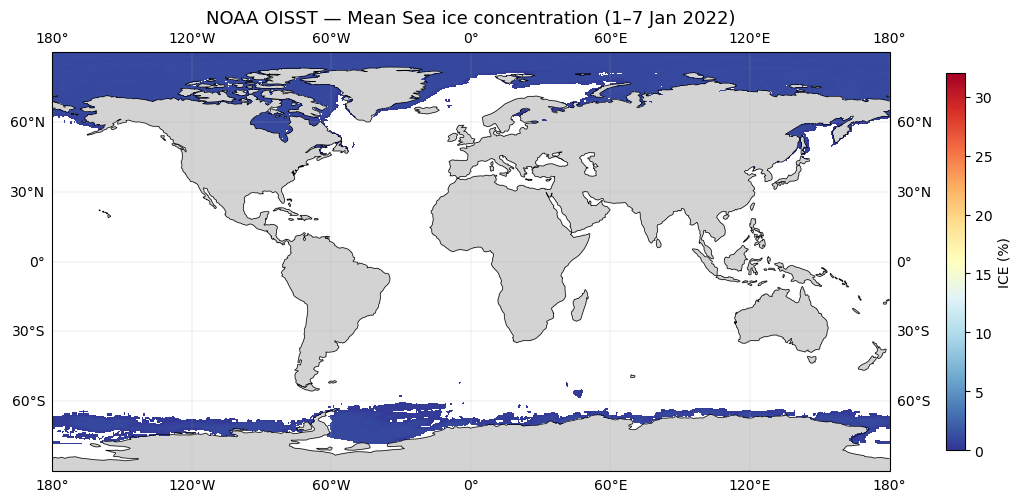

In [23]:
# ── Plot: mean ICE first week of January 2022 ──

ice_mean = ds_sst["ice"].isel(zlev=0).mean(dim="time")

fig, ax = plt.subplots(
    figsize=(12, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
ax.add_feature(cfeature.LAND, color="lightgray")
ax.coastlines(linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

p = ax.pcolormesh(
    ice_mean.lon, ice_mean.lat, ice_mean,
    transform=ccrs.PlateCarree(), cmap="RdYlBu_r", vmin=0, vmax=32
)
fig.colorbar(p, ax=ax, label="ICE (%)", shrink=0.9)
ax.set_title("NOAA OISST — Mean Sea ice concentration (1–7 Jan 2022)", fontsize=13)
fig.tight_layout()
#plt.show()


---

# 5. UK Met Office EN4 — Ocean Temperature & Salinity

## 📖 Description

**EN4** is a global, quality-controlled dataset of **sub-surface ocean temperature and salinity profiles** produced by the **UK Met Office Hadley Centre**. It is the fourth version of the Met Office's EN ("Ensemble") series of ocean observation databases.

EN4 provides **two complementary products**: (1) a database of individual in situ profiles with quality control flags, and (2) **monthly objective analysis fields** on a 1° × 1° horizontal grid with 42 depth levels, spanning **83°S to 90°N from 1900 to present**. Input data come from **Argo floats, the World Ocean Database (WOD), GTSPP, and ASBO**.

Unlike a reanalysis, EN4 does not use a circulation model — it applies **Optimal Interpolation** to the in situ profiles, relaxing to climatology in data-sparse regions and time periods. Uncertainty estimates (analysis error standard deviations) are provided for depth levels above 1000 m. EN4 is widely used for monitoring **ocean heat content**, **thermosteric sea level**, model validation, and satellite salinity calibration.

The current version is **EN4.2.2**, with bias corrections available from several methods (the recommended one being Gouretski & Cheng 2020, designated `.g10`).

### 📦 Key Variables (Objective Analysis files)

| Variable | Description |
|----------|-------------|
| `temperature` | Potential temperature (°C), 42 depth levels |
| `salinity` | Practical salinity (PSU), 42 depth levels |
| `temperature_uncertainty` | Analysis error std for temperature |
| `salinity_uncertainty` | Analysis error std for salinity |
| `depth` | 42 depth levels from ~5 m to ~5350 m |

### 🌐 Dataset URLs
> **Met Office EN4 homepage:**  
> https://www.metoffice.gov.uk/hadobs/en4/  
> **Direct download page (EN4.2.2):**  
> https://www.metoffice.gov.uk/hadobs/en4/download-en4-2-2.html  
> **License:** Open Government Licence v3 (UK) — free, attribution required

---

## ⬇️ Download UK Met Office EN4 Data

In [24]:
# ─────────────────────────────────────────────────────────────────
# EN4 — Download monthly objective analysis files
#
# File naming convention:
#   EN.4.2.2.f.analysis.g10.YYYYMM.nc
#
# Files are hosted at:
#   https://www.metoffice.gov.uk/hadobs/en4/data/en4-2-2/
# ─────────────────────────────────────────────────────────────────

import requests, os
from tqdm import tqdm

EN4_BASE = "http://www.metoffice.gov.uk/hadobs/en4/data/en4-2-1/EN.4.2.2/"

def en4_filename(year, month, correction="g10"):
    """Return the EN4.2.2 analysis filename for a given year/month."""
    return f"EN.4.2.2.f.analysis.{correction}.{year}{month:02d}.zip"

def download_en4(year, month, out_dir="./data/en4", correction="g10"):
    os.makedirs(out_dir, exist_ok=True)
    fname = en4_filename(year, month, correction)
    url   = EN4_BASE + fname
    fpath = os.path.join(out_dir, fname)
    if os.path.exists(fpath):
        print(f"📂 Already exists: {fpath}")
        return fpath
    r = requests.get(url, stream=True, timeout=120)
    r.raise_for_status()
    total = int(r.headers.get("content-length", 0))
    with open(fpath, "wb") as f, tqdm(
        desc=fname, total=total, unit="B",
        unit_scale=True, unit_divisor=1024
    ) as bar:
        for chunk in r.iter_content(1024 * 512):
            f.write(chunk)
            bar.update(len(chunk))
    print(f"✅ Downloaded: {fpath}")
    return fpath

# Download 12 months (year 2020) — each file ~ 8 MB
en4_files = []
for month in range(1, 13):
    en4_files.append(download_en4(2020, month))


HTTPError: 404 Client Error: Not Found for url: https://www.metoffice.gov.uk/hadobs/en4/data/en4-2-1/EN.4.2.2/EN.4.2.2.f.analysis.g10.202001.zip

In [ ]:
# ── Alternatively: download an entire year as a ZIP archive ──
# EN4 also provides per-year ZIP files for convenience.

def download_en4_year_zip(year, out_dir="./data/en4", correction="g10"):
    os.makedirs(out_dir, exist_ok=True)
    fname = f"EN.4.2.2.analyses.{correction}.{year}.zip"
    url   = EN4_BASE + fname
    fpath = os.path.join(out_dir, fname)
    if os.path.exists(fpath):
        print(f"📂 Already exists: {fpath}")
        return fpath
    r = requests.get(url, stream=True, timeout=300)
    r.raise_for_status()
    total = int(r.headers.get("content-length", 0))
    with open(fpath, "wb") as f, tqdm(
        desc=fname, total=total, unit="B",
        unit_scale=True, unit_divisor=1024
    ) as bar:
        for chunk in r.iter_content(1024 * 1024):
            f.write(chunk)
            bar.update(len(chunk))
    print(f"✅ Downloaded: {fpath}")
    return fpath

# Uncomment to download all of 2020 in one ZIP (~100 MB):
# download_en4_year_zip(2020)


In [ ]:
# ── Open and inspect ──
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Open all 12 months as a single dataset
ds_en4 = xr.open_mfdataset(
    "./data/en4/EN.4.2.2.f.analysis.g10.2020*.nc",
    combine="by_coords"
)
print(ds_en4)


In [ ]:
# ── Plot: Annual-mean sea surface salinity (top level) ──
sal_surface = ds_en4["salinity"].isel(depth=0).mean(dim="time")

fig, ax = plt.subplots(
    figsize=(14, 6),
    subplot_kw={"projection": ccrs.Robinson()}
)
ax.add_feature(cfeature.LAND, color="lightgray")
ax.coastlines(linewidth=0.5)
ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)

p = ax.pcolormesh(
    ds_en4.lon, ds_en4.lat, sal_surface,
    transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=30, vmax=38
)
plt.colorbar(p, ax=ax, orientation="horizontal",
             label="Salinity (PSU)", pad=0.05, shrink=0.8)
ax.set_title("UK Met Office EN4 — Annual Mean Sea Surface Salinity (2020)", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── Plot: Vertical salinity profile at a location ──
# Example: North Atlantic subtropical gyre (~30°N, 330°E)

sal_profile = (
    ds_en4["salinity"]
    .sel(lat=30, lon=330, method="nearest")
    .mean(dim="time")
)
depths = ds_en4.depth.values

fig, ax = plt.subplots(figsize=(5, 8))
ax.plot(sal_profile, depths, color="steelblue", linewidth=2)
ax.invert_yaxis()
ax.set_xlabel("Salinity (PSU)", fontsize=12)
ax.set_ylabel("Depth (m)", fontsize=12)
ax.set_title("EN4 — Salinity Profile\n30°N, 30°W (2020 mean)", fontsize=12)
ax.set_ylim(2000, 0)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()


---

# 📋 Quick Reference Summary

| Dataset | Variable | Temporal Coverage | Resolution | Format | Python Access |
|---------|----------|------------------|------------|--------|--------------|
| **SOCAT** | Surface fCO₂ | 1957 – 2023 | Point obs / 1° gridded | TSV / NetCDF | `requests` + URL |
| **GlobColour** | CHL, SPM, RRS… | 1997 – present | 4 km, 300 m | NetCDF | `copernicusmarine` |
| **ERA5** | Winds, T, P, fluxes | 1940 – present | 0.25° (~31 km), hourly | NetCDF / GRIB | `cdsapi` |
| **NOAA OISST** | SST, SST anomaly | Sep 1981 – present | 0.25°, daily | NetCDF | `requests` / OPeNDAP |
| **Met Office EN4** | T & S profiles, gridded | 1900 – present | 1°, 42 depth levels, monthly | NetCDF | `requests` + URL |

---

## 🔗 All Links at a Glance

| Dataset | Homepage | Direct Download / API |
|---------|----------|-----------------------|
| SOCAT | https://socat.info | https://socat.info/index.php/data-access/ |
| GlobColour | https://data.marine.copernicus.eu/product/OCEANCOLOUR_GLO_BGC_L3_MY_009_103 | `pip install copernicusmarine` |
| ERA5 | https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels | `pip install cdsapi` |
| NOAA OISST | https://www.ncei.noaa.gov/products/optimum-interpolation-sst | https://www.ncei.noaa.gov/data/sea-surface-temperature-optimum-interpolation/v2.1/access/avhrr/ |
| Met Office EN4 | https://www.metoffice.gov.uk/hadobs/en4/ | https://www.metoffice.gov.uk/hadobs/en4/download-en4-2-2.html |

---

## 📚 Key References

- **SOCAT:** Bakker et al. (2016). *Earth Syst. Sci. Data*, 8, 383–413. https://doi.org/10.5194/essd-8-383-2016
- **GlobColour / CMEMS:** CMEMS Ocean Colour Thematic Assembly Centre. https://doi.org/10.48670/moi-00279
- **ERA5:** Hersbach et al. (2020). *Q. J. R. Meteorol. Soc.*, 146, 1999–2049. https://doi.org/10.1002/qj.3803
- **NOAA OISST:** Huang et al. (2020). *J. Climate*, 34, 2923–2939. https://doi.org/10.1175/JCLI-D-20-0166.1
- **EN4:** Good et al. (2013). *J. Geophys. Res. Oceans*, 118, 6704–6716. https://doi.org/10.1002/2013JC009067

---
*Notebook prepared for workshop use. Always cite the original dataset papers and check each provider's website for the most current version and access instructions.*